✅ Загружено 75 строк

=== ПЕРВЫЕ 5 СТРОК ===
   gender_male  gender_female  activities_none  activities_medium  \
0            0              1                0                  1   
1            1              0                0                  0   
2            1              0                0                  0   
3            1              0                0                  1   
4            0              1                0                  1   

   activities_high  living_семья  living_общежитие  living_самостоятельно  \
0                0             1                 0                      0   
1                0             1                 0                      0   
2                0             1                 0                      0   
3                0             1                 0                      0   
4                0             1                 0                      0   

   study_hours  study_load  sleep_hours  fatigue  free_time  sport  \
0      

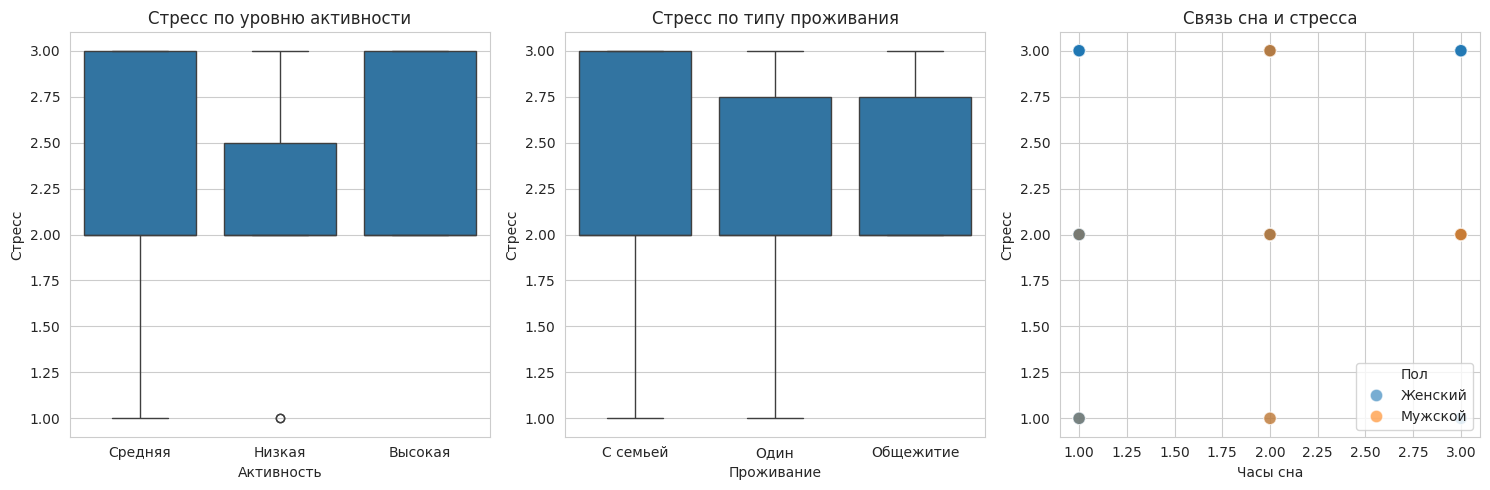


=== МУЖЧИНЫ VS ЖЕНЩИНЫ ===
✓ stress: Женщины выше на 0.30 (p=0.034)
  satisfaction: нет значимых различий (p=0.612)
  sleep_hours: нет значимых различий (p=0.565)
  study_hours: нет значимых различий (p=0.289)

=== ВЫВОДЫ ===
1. Средний уровень стресса: 2.29 из 3
2. Лучше всего стресс снижает: satisfaction (-0.26)
3. Больше всего стресс повышает: activities_none (nan)
4. Студентов со стрессом выше 2: 28 из 75 (37%)


In [4]:
# Импорт
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

data = {
    'gender_male': [0,1,1,1,0,0,0,0,1,1,1,1,0,0,0,1,1,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,1,0,1,1,1,0,0,1,1,0,1,0,0,1,1,1,0,0,0,1,1,0,0,1,0,1,0,1,0,0,1,0,0,1,1,1,1,0,1,0],
    'gender_female': [1,0,0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0,1,0,1,1,1,1,1,0,1,1,1,1,0,1,0,1,0,0,1,0,0,0,1,1,0,0,1,0,1,1,0,0,0,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,1,1,0,0,0,0,1,0,1],
    'activities_none': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'activities_medium': [1,0,0,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,0,1,0,1,1,1,0,1,1,0,1,0,0,0,1,1,1,1,0,1,1,0,1,0,1,0,1,0,1,1,0,0,1,1,0,0],
    'activities_high': [0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,1,1],
    'living_семья': [1,1,1,1,1,0,1,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,0,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0,0,1,0,0,1,1,1,1,1,1,1,0,1,1,0,0,1,0,0,1,0,0,1,1,0,1],
    'living_общежитие': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,1,0,0,1,0],
    'living_самостоятельно': [0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'study_hours': [2,3,1,2,1,3,2,1,2,1,2,2,3,3,1,1,2,2,1,2,1,1,2,2,1,3,2,2,1,2,2,1,1,2,3,3,2,1,2,1,1,3,2,2,1,3,1,2,3,2,3,2,3,2,2,2,2,1,2,2,1,1,2,2,1,2,2,3,2,3,1,1,2,1,2],
    'study_load': [1,3,1,2,3,3,3,2,2,2,2,3,3,2,1,2,2,2,2,3,1,1,2,2,2,2,2,2,2,2,2,2,1,2,3,2,3,2,2,2,2,2,2,2,2,3,2,2,3,1,3,3,3,2,1,2,3,2,2,2,2,2,3,2,2,2,2,1,2,2,2,1,2,3,2],
    'sleep_hours': [2,2,1,1,2,1,2,2,2,2,1,1,1,1,1,2,1,1,1,1,3,2,2,2,2,3,2,2,3,3,3,2,1,2,2,2,1,2,3,1,1,1,2,3,2,2,1,1,1,1,2,3,1,3,2,3,3,2,2,2,1,2,2,2,2,2,3,2,1,1,3,2,1,1,1],
    'fatigue': [2,1,1,2,3,3,2,3,2,2,2,3,3,2,3,2,3,2,3,3,1,3,3,3,2,2,2,2,2,2,2,2,3,3,3,3,2,2,2,2,2,3,2,2,2,1,3,3,1,3,2,1,3,2,3,3,2,3,2,1,2,3,3,2,2,1,3,3,1,2,1,3,3,2,1],
    'free_time': [3,1,2,2,1,1,3,1,2,1,2,1,2,3,3,3,2,1,1,1,1,2,2,2,2,2,2,2,3,1,3,2,2,2,3,3,1,3,2,3,1,1,2,3,2,1,2,3,2,3,2,2,2,3,1,2,3,3,2,3,1,1,2,3,2,3,1,2,3,3,3,2,1,2,1],
    'sport': [3,3,2,1,1,1,2,1,2,1,2,3,1,2,2,2,3,2,1,2,1,1,1,1,1,2,1,2,2,2,3,3,1,2,1,2,2,1,1,2,2,2,3,3,1,2,1,1,2,1,2,2,1,1,2,2,1,2,1,2,1,2,1,2,1,2,2,1,2,3,1,3,2,1,1],
    'satisfaction': [3,2,3,2,2,2,2,1,2,2,3,2,1,2,1,3,2,2,1,1,1,2,2,2,2,2,3,3,3,2,3,3,2,2,1,1,2,2,1,2,1,2,1,2,2,2,1,2,2,2,1,2,1,2,2,2,2,2,2,2,3,2,2,3,1,3,3,2,2,2,1,3,1,3,3],
    'procrastination': [3,2,2,1,2,2,1,3,2,1,2,1,3,2,2,3,2,3,3,3,3,3,3,2,2,2,2,2,1,2,3,2,3,2,1,3,2,1,1,3,2,1,3,2,1,2,3,2,1,2,2,2,2,3,3,1,2,3,1,3,3,2,2,2,3,2,3,2,1,2,2,2,2,2,1],
    'deadline_success': [2,3,1,2,2,2,3,2,2,2,1,1,2,2,2,2,3,1,1,2,3,2,2,2,2,3,3,3,3,2,3,2,1,1,3,1,2,3,1,2,2,2,3,2,2,2,2,2,3,3,2,2,3,1,2,3,1,1,2,2,2,2,2,3,2,2,3,3,3,2,2,2,2,3,2],
    'stress': [2,2,1,2,3,3,2,3,2,3,2,3,2,3,3,3,2,2,3,2,3,3,3,3,2,2,2,2,1,2,2,1,1,3,2,2,1,3,2,2,2,2,2,2,2,3,3,3,2,2,3,3,3,3,3,2,2,3,1,2,2,2,2,2,2,2,3,3,2,2,2,3,3,2,2],
    'interest_for_study': [1,3,2,2,2,3,2,2,2,1,3,1,2,3,2,2,2,2,2,2,1,2,2,3,3,2,3,3,3,3,3,3,2,3,2,3,2,2,3,3,2,3,2,2,1,3,2,2,3,3,3,2,2,2,3,3,2,2,1,3,1,3,2,2,1,2,2,3,2,3,2,2,3,2,1]
}

df = pd.DataFrame(data)

print(f"✅ Загружено {len(df)} строк")
print("\n=== ПЕРВЫЕ 5 СТРОК ===")
print(df.head())

# Базовый анализ (только числовые колонки)
print("\n=== ОСНОВНЫЕ ПОКАЗАТЕЛИ ===")
print(f"Стресс: {df['stress'].mean():.2f}/3")
print(f"Удовлетворенность: {df['satisfaction'].mean():.2f}/3")
print(f"Сон: {df['sleep_hours'].mean():.1f}ч")
print(f"Учеба: {df['study_hours'].mean():.1f}ч")
print(f"Спорт: {df['sport'].mean():.1f} (1-3)")

# Корреляции со стрессом (только числовые колонки)
print("\n=== ЧТО ВЛИЯЕТ НА СТРЕСС ===")
# Берем только числовые колонки для корреляции
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stress_corr = df[numeric_cols].corr()['stress'].drop('stress').sort_values()

print("Топ-3 фактора, снижающих стресс (отрицательная корреляция):")
for var, corr in stress_corr.head(3).items():
    print(f"  {var}: {corr:.2f}")

print("\nТоп-3 фактора, повышающих стресс (положительная корреляция):")
for var, corr in stress_corr.tail(3).iloc[::-1].items():
    print(f"  {var}: {corr:.2f}")

# Добавляем текстовые колонки для графиков
df['gender'] = df['gender_male'].map({1: 'Мужской', 0: 'Женский'})

# Восстановление категорий для графиков
activity_cols = ['activities_none', 'activities_medium', 'activities_high']
df['activity'] = df[activity_cols].idxmax(axis=1).map({
    'activities_none': 'Низкая',
    'activities_medium': 'Средняя',
    'activities_high': 'Высокая'
})

living_cols = ['living_семья', 'living_общежитие', 'living_самостоятельно']
df['living'] = df[living_cols].idxmax(axis=1).map({
    'living_семья': 'С семьей',
    'living_общежитие': 'Общежитие',
    'living_самостоятельно': 'Один'
})

# Графики
sns.set_style("whitegrid")
plt.figure(figsize=(15, 5))

# 1. Стресс vs активность
plt.subplot(1, 3, 1)
sns.boxplot(x='activity', y='stress', data=df)
plt.title('Стресс по уровню активности', fontsize=12)
plt.xlabel('Активность')
plt.ylabel('Стресс')

# 2. Стресс vs проживание
plt.subplot(1, 3, 2)
sns.boxplot(x='living', y='stress', data=df)
plt.title('Стресс по типу проживания', fontsize=12)
plt.xlabel('Проживание')
plt.ylabel('Стресс')

# 3. Сон vs стресс
plt.subplot(1, 3, 3)
sns.scatterplot(x='sleep_hours', y='stress', hue='gender', data=df, alpha=0.6, s=80)
plt.title('Связь сна и стресса', fontsize=12)
plt.xlabel('Часы сна')
plt.ylabel('Стресс')
plt.legend(title='Пол')

plt.tight_layout()
plt.show()

# Гендерные различия
print("\n=== МУЖЧИНЫ VS ЖЕНЩИНЫ ===")
for metric in ['stress', 'satisfaction', 'sleep_hours', 'study_hours']:
    male = df[df['gender_male']==1][metric]
    female = df[df['gender_male']==0][metric]
    t_stat, p_val = stats.ttest_ind(male, female)
    diff = male.mean() - female.mean()
    if p_val < 0.05:
        print(f"✓ {metric}: {'Мужчины выше' if diff>0 else 'Женщины выше'} на {abs(diff):.2f} (p={p_val:.3f})")
    else:
        print(f"  {metric}: нет значимых различий (p={p_val:.3f})")

print("\n=== ВЫВОДЫ ===")
print(f"1. Средний уровень стресса: {df['stress'].mean():.2f} из 3")
print(f"2. Лучше всего стресс снижает: {stress_corr.head(1).index[0]} ({stress_corr.head(1).values[0]:.2f})")
print(f"3. Больше всего стресс повышает: {stress_corr.tail(1).index[0]} ({stress_corr.tail(1).values[0]:.2f})")
print(f"4. Студентов со стрессом выше 2: {len(df[df['stress']>2])} из {len(df)} ({len(df[df['stress']>2])/len(df)*100:.0f}%)")
